In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
PT_FILES = '/Users/ash/Library/CloudStorage/OneDrive-Nexus365/PHD/spatial data/wytham/RFID_DATA'

In [4]:
df_2012 = pd.read_csv(f'{PT_FILES}/2012/records.csv')

In [5]:
df_2012.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5704247 entries, 0 to 5704246
Data columns (total 4 columns):
 #   Column          Dtype 
---  ------          ----- 
 0   id              object
 1   location        object
 2   time            object
 3   antenna_number  int64 
dtypes: int64(1), object(3)
memory usage: 174.1+ MB


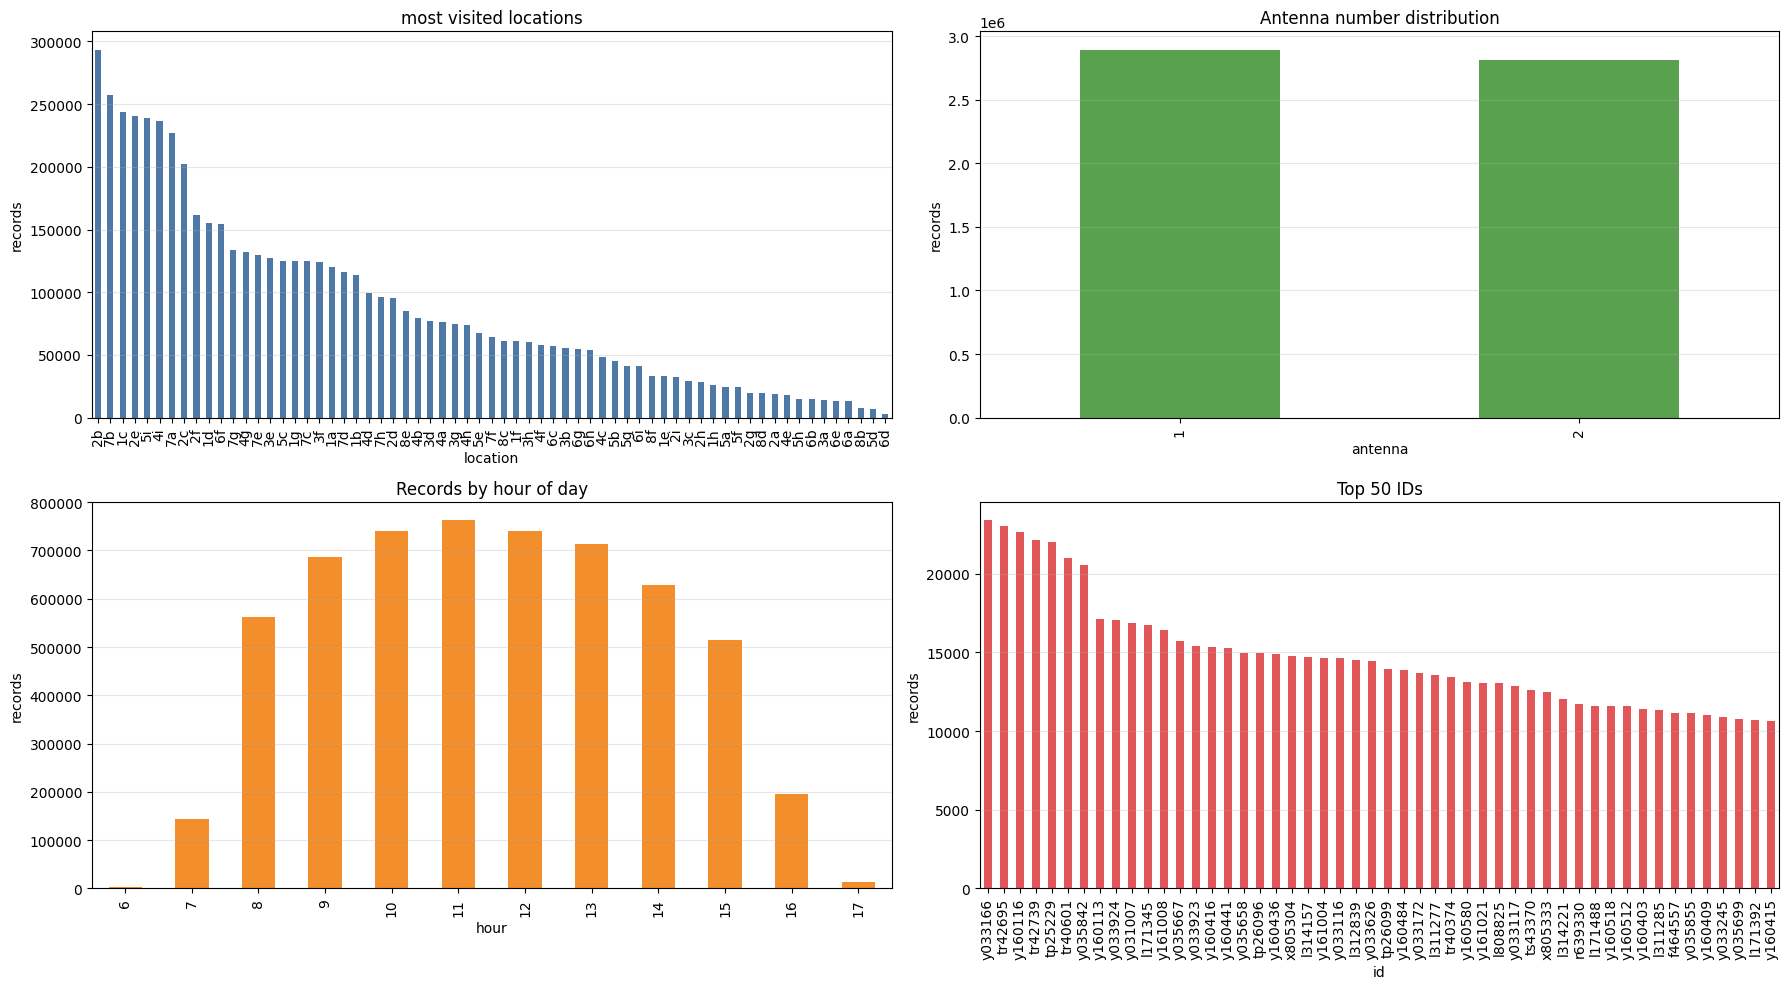

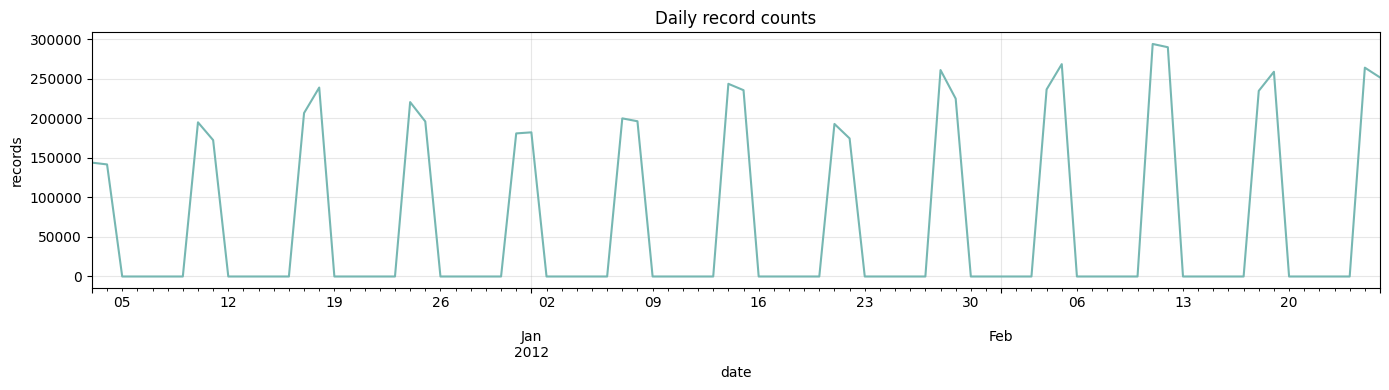

In [12]:
# Summary plots for df_2012

# Convert time to datetime once
if 'time_dt' not in df_2012.columns:
    df_2012['time_dt'] = pd.to_datetime(df_2012['time'], errors='coerce')

# Aggregations
loc_counts = df_2012['location'].value_counts()#.head(20)
ant_counts = df_2012['antenna_number'].value_counts().sort_index()
id_counts = df_2012['id'].value_counts().head(50)
hours = df_2012['time_dt'].dropna().dt.hour.value_counts().sort_index()
daily = (
    df_2012.dropna(subset=['time_dt'])
    .groupby(pd.Grouper(key='time_dt', freq='D'))
    .size()
)

# 2x2 summary grid
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

loc_counts.plot(kind='bar', ax=axes[0, 0], color='#4e79a7', title='most visited locations')
axes[0, 0].set_xlabel('location')
axes[0, 0].set_ylabel('records')
axes[0, 0].grid(alpha=0.3, axis='y')

ant_counts.plot(kind='bar', ax=axes[0, 1], color='#59a14f', title='Antenna number distribution')
axes[0, 1].set_xlabel('antenna')
axes[0, 1].set_ylabel('records')
axes[0, 1].grid(alpha=0.3, axis='y')

hours.plot(kind='bar', ax=axes[1, 0], color='#f28e2b', title='Records by hour of day')
axes[1, 0].set_xlabel('hour')
axes[1, 0].set_ylabel('records')
axes[1, 0].grid(alpha=0.3, axis='y')

id_counts.plot(kind='bar', ax=axes[1, 1], color='#e15759', title='Top 50 IDs')
axes[1, 1].set_xlabel('id')
axes[1, 1].set_ylabel('records')
axes[1, 1].grid(alpha=0.3, axis='y')
for tick in axes[1, 1].get_xticklabels():
    tick.set_rotation(90)

plt.tight_layout()

# Daily time series
plt.figure(figsize=(14, 4))
daily.plot(kind='line', color='#76b7b2', title='Daily record counts')
plt.xlabel('date')
plt.ylabel('records')
plt.grid(alpha=0.3)
plt.tight_layout()